# Propensity score estimation

This is example is directly taken from:  https://matheusfacure.github.io/python-causality-handbook/11-Propensity-Score.html

In [1]:
import pandas as pd
import numpy as np
from matplotlib import style
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.linear_model import LogisticRegression
from causalinference import CausalModel

sns.set_theme()

Below we use replication data from: https://github.com/grf-labs/grf/tree/master/experiments/acic18.

See Athey and Wagner (2019) for details: https://arxiv.org/pdf/1902.07409

* S3 - Students' self-reported expectations for success in the future, a proxy for prior achievement, measured prior to random assignment
* C1 - Categorical variable for student race/ethnicity
* C2 - Categorical variable for student identified gender
* C3 - Categorical variable for student first-generation status (i.e. first in family to go to college)
* XC - School-level categorical variable for urbanicity of the school (i.e. rural, suburban, etc.)
* X1 - School-level mean of students' fixed mindsets, reported prior to random assignment
* X2 - School achievement level, as measured by test scores and college preparation for the previous 4 cohorts of students
* X3 - School racial/ethnic minority composition -- i.e. % black, latino, or native/american
* X4 - School poverty concentration -- i.e. % of students who are from families whose incomes fall below the federal poverty line
* X5 - School size - Total # of students in all four grade levels in the school

In [2]:
# # df = pd.read_csv('data/synthetic_data.csv')
# # Actual data from the study
# url = "https://raw.githubusercontent.com/grf-labs/grf/refs/heads/master/experiments/acic18/synthetic_data.csv"

# data from the companion site
url = "https://raw.githubusercontent.com/matheusfacure/python-causality-handbook/refs/heads/master/causal-inference-for-the-brave-and-true/data/learning_mindset.csv"

df = pd.read_csv(url)

# # if using actual data from the study, you may want to rename variables
# df.rename(columns={
#     'Z': 'intervention', 'Y': 'achievement_score',
#     'S3': 'success_expect',
#     'C1': 'ethnicity', 'C2': 'gender', 'C3': 'first_in_family',
#     'XC': 'school_urbanicity',
#     'X1': 'school_mindset', 'X2': 'school_achievement', 'X3': 'school_ethnic_minority',
#     'X4': 'school_poverty', 'X5': 'school_size'
# }, inplace=True)

print(f'Shape of df: {df.shape}')
assert ~(df.isna().any().any())
df.head()

Shape of df: (10391, 13)


,schoolid,intervention,achievement_score,success_expect,ethnicity,gender,frst_in_family,school_urbanicity,school_mindset,school_achievement,school_ethnic_minority,school_poverty,school_size
0,76,1,0.277359,6,4,2,1,4,0.334544,0.648586,-1.310927,0.224077,-0.426757
1,76,1,-0.449646,4,12,2,1,4,0.334544,0.648586,-1.310927,0.224077,-0.426757
2,76,1,0.769703,6,4,2,0,4,0.334544,0.648586,-1.310927,0.224077,-0.426757
3,76,1,-0.121763,6,4,2,0,4,0.334544,0.648586,-1.310927,0.224077,-0.426757
4,76,1,1.526147,6,4,1,0,4,0.334544,0.648586,-1.310927,0.224077,-0.426757


## Evidence of confounding

The intervention doesn't appear to be random; for example, students with higher expectations of success
are more likely to receive the intervention

Text(0.5, 1.0, 'Average in NSLM data')

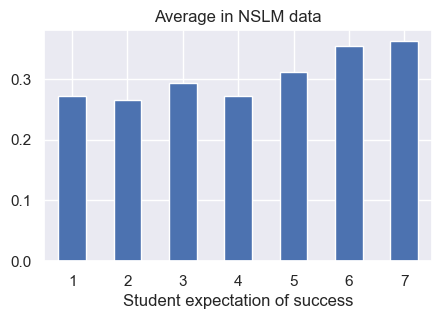

In [3]:
plot_df = df.groupby('success_expect')['intervention'].mean()
# df.groupby('success_expect')['intervention'].mean().plot().bar()

fig, ax = plt.subplots(figsize=(5,3))
plot_df.plot(kind='bar', ax=ax)

ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

ax.set_xlabel('Student expectation of success')
ax.set_title('Average in NSLM data')

Average treatment effects are likley to be biased

In [4]:
mean_df = df.groupby(['intervention'])['achievement_score'].mean()
np.round(mean_df[1] - mean_df[0], 4)

np.float64(0.4723)

In [5]:
mean_diff = (
    df.loc[df['intervention'] == 1, 'achievement_score'].mean()
    - df.loc[df['intervention'] == 0, 'achievement_score'].mean()
)
print(f'Biased treatment effect: {mean_diff:.4f}')

Biased treatment effect: 0.4723


In [6]:
ols_mod = smf.ols("achievement_score ~ intervention", data=df)
ols_res = ols_mod.fit()
ols_res.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.1538,0.012,-13.201,0.000,-0.177,-0.131
intervention,0.4723,0.020,23.133,0.000,0.432,0.512


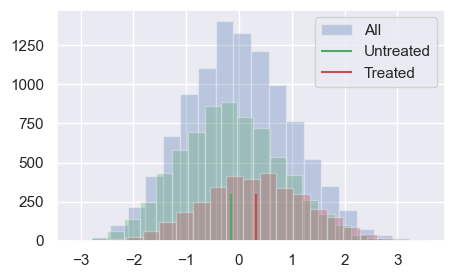

In [7]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.hist(df["achievement_score"], bins=20, alpha=0.3, label="All")
ax.hist(df.query("intervention==0")["achievement_score"], bins=20, alpha=0.3, color="C2")
ax.hist(df.query("intervention==1")["achievement_score"], bins=20, alpha=0.3, color="C3")
ax.vlines(ols_res.params['Intercept'], 0, 300, label="Untreated", color="C2")
ax.vlines(ols_res.params.sum(), 0, 300, label="Treated", color="C3")
ax.legend()

plt.show()

## Propensity scores

Propensity score

Propensity score definition: $p(X_i) = \mathbf{E} [D_i \vert X_i] = \mathbf{P} (D_i = 1 \vert X_i)$
$$
\begin{align}
p(X_i) =& \mathbf{E} [D_i \vert X_i] \\
=& \sum_{d=0}^1 d \cdot \mathbf{P} (D_i = d \vert X_i) \\
=& 0 \cdot \mathbf{P} (D_i = 0 \vert X_i) + 1 \cdot \mathbf{P} (D_i = 1 \vert X_i) \\
=& \mathbf{P} (D_i = 1 \vert X_i)
\end{align}
$$

Fact #1: $\mathbf{E} \left[ \frac{Y_i D_i}{p(X_i)} \right] = \mathbf{E} [Y_{1i}]$

Fact #2: $\mathbf{E} \left[ \frac{Y_i (1 - D_i)}{1 - p(X_i)} \right] = \mathbf{E} [Y_{0i}]$

Average treatment effect can be defined as:
$$
\begin{align}
\mathbf{E} [Y_{1i} - Y_{0i}]
=& \mathbf{E} 
\left[ 
    \frac{Y_i D_i}{p(X_i)}
    - \frac{Y_i (1 - D_i)}{1 - p(X_i)}
\right] \\
=& \mathbf{E} \left[ \frac{Y_i D_i (1 - p(X_i)) - Y_i (1 - D_i) p(X_i)}{p(X_i) (1 - p(X_i))} \right] \\
=& \mathbf{E} \left[ \frac{Y_i \left[ D_i (1 - p(X_i)) - (1 - D_i) p(X_i) \right]}{p(X_i) (1 - p(X_i))} \right] \\
=& \mathbf{E} \left[ \frac{Y_i \left[ D_i - D_i p(X_i) - p(X_i) +  D_i p(X_i) \right]}{p(X_i) (1 - p(X_i))} \right] \\
=& \mathbf{E} \left[ \frac{Y_i \left[ D_i - p(X_i) \right]}{p(X_i) (1 - p(X_i))} \right] \\
\end{align}
$$

### Generate propensity score

In [8]:
categorical_vars = ["ethnicity", "gender", "school_urbanicity"]

design_matrix = pd.concat([
    df.drop(columns=(categorical_vars)),
    pd.get_dummies(df[categorical_vars], columns=categorical_vars, drop_first=False)
], axis=1)

t_col = 'intervention'
y_col = 'achievement_score'

t_var = design_matrix[t_col]
y_var = design_matrix[y_col]
X_var = design_matrix.drop(columns=(['schoolid'] + [y_col, t_col]))

# design_matrix.drop()
design_matrix.shape

(10391, 32)

In [9]:
ps_mod = LogisticRegression()
ps_mod.fit(X=X_var, y=t_var)

# return predicted probabilities. Note that the actual df returned by predict_propa
# has a column for treatement (1) and control (0). These refer to the 
# ps_mod.classes_

ps_series = pd.Series(ps_mod.predict_proba(X_var)[:, 1], name='propensity_score')
ps_df = pd.concat([y_var, t_var, ps_series], axis=1)
ps_df = pd.concat([ps_df, X_var], axis=1)

ps_df[['intervention', 'achievement_score', 'propensity_score']].head()

,intervention,achievement_score,propensity_score
0,1,0.277359,0.315460
1,1,-0.449646,0.264334
2,1,0.769703,0.344090
3,1,-0.121763,0.344090
4,1,1.526147,0.367617


In [10]:

ps_df['achievement_score'] * ps_df['propensity_score']

0        0.087496
1       -0.118857
2        0.264847
3       -0.041897
4        0.561037
           ...   
10386    0.261699
10387   -0.050492
10388    0.092338
10389   -0.119901
10390    0.122638
Length: 10391, dtype: float64

The propensity score makes populations where everyone looks like they were treated (using weights $1 / p(X)$)
and like everyone was untreated (using weights $1 / (1 - p(X))$).

In [11]:
print(f'Number of observations: {len(ps_df):,}')

weight_t = ((1 / ps_df['propensity_score']) * ps_df['intervention'])
weight_nt = (1 / (1 - ps_df['propensity_score']) * (1 - ps_df['intervention']))

print(f'"Treated" population size (using propensity weights): {weight_t.sum():.2f}')
print(f'"Untreated" population size (using propensity weights): {weight_nt.sum():.2f}')

Number of observations: 10,391
"Treated" population size (using propensity weights): 10385.06
"Untreated" population size (using propensity weights): 10391.79


Propensity scores can provide evidence of confounding (resulting in selection bias).
Below, propensity score rises with expectation of success; that indicates that 
students with higher expectations of success are more likely to seek treatment.

<Axes: xlabel='success_expect', ylabel='propensity_score'>

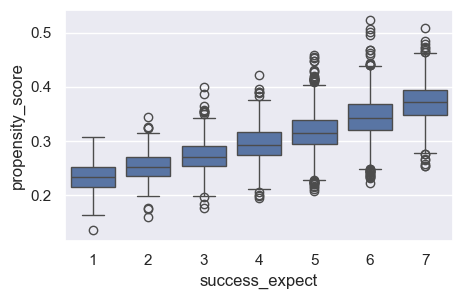

In [12]:
fig, ax = plt.subplots(figsize=(5, 3))

sns.boxplot(x='success_expect', y='propensity_score', data=ps_df, ax=ax)

Evaluate that there is overlap in propensity score between treated and untreated population.
Notice that there is generally overlap in propensity scores.
However, you may want to trim to only include propensity scores with positive overlap.

<Axes: xlabel='propensity_score', ylabel='Frequency'>

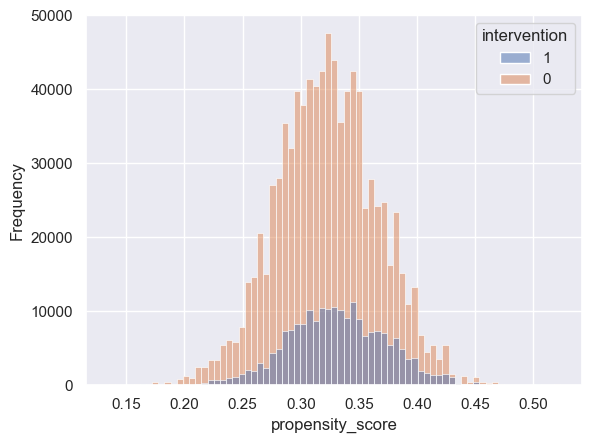

In [13]:
# sns.histplot(ps_df.loc[ps_df['intervention'] == 0, 'propensity_score'])
# sns.histplot(ps_df['propensity_score'], hue=ps_df['intervention'])
sns.histplot(data=ps_df, x='propensity_score', hue='intervention', stat='frequency', hue_order=[1, 0])

## Treatment effects

### Using Horvitz-Thompson approach
$$\mathbf{E} \left[ \frac{Y_i \left[ D_i - p(X_i) \right]}{p(X_i) (1 - p(X_i))} \right]$$

In [14]:
np.mean((ps_df[y_col] * (ps_df[t_col] - ps_df['propensity_score'])) / (ps_df['propensity_score'] * (1 - ps_df['propensity_score'])))

np.float64(0.38917723627279377)

#### Equivalent: Calculating ATE

In [15]:
est_y1 = (ps_df['achievement_score'] * ps_df['intervention']) / ps_df['propensity_score']
est_y0 = (ps_df['achievement_score'] * (1 - ps_df['intervention'])) / (1 - ps_df['propensity_score'])

(est_y1 - est_y0).mean()

np.float64(0.38917723627279377)

### Using propensity score and OLS

In [16]:
ols_mod = smf.ols('achievement_score ~ intervention + propensity_score', data=ps_df)
ols_res = ols_mod.fit()

ols_res.summary(slim=True)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      achievement_score   R-squared:                       0.206
Model:                            OLS   Adj. R-squared:                  0.206
No. Observations:               10391   F-statistic:                     1350.
Covariance Type:            nonrobust   Prob (F-statistic):               0.00
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -3.1101      0.066    -47.118      0.000      -3.240      -2.981
intervention         0.3929      0.019     20.976      0.000       0.356       0.430
propensity_score     9.1557      0.202     45.382      0.000       8.760       9.551
====================================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [17]:
sm.OLS(endog=(ps_df['achievement_score'] / ps_df['propensity_score']), exog=sm.add_constant(ps_df['intervention'])).fit().summary(slim=True)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
No. Observations:               10391   F-statistic:                     503.9
Covariance Type:            nonrobust   Prob (F-statistic):          5.25e-109
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.6480      0.037    -17.621      0.000      -0.720      -0.576
intervention     1.4465      0.064     22.447      0.000       1.320       1.573
================================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Propensity score and matching

In [18]:
cm = CausalModel (
    Y = ps_df['achievement_score'].values,
    D = ps_df['intervention'].values,
    X = ps_df[['propensity_score']].values
)
cm.est_via_matching(matches=1, bias_adj=True)
print(cm.estimates)


Treatment Effect Estimates: Matching

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE      0.386      0.025     15.425      0.000      0.337      0.436
           ATC      0.372      0.027     13.561      0.000      0.318      0.426
           ATT      0.416      0.027     15.460      0.000      0.363      0.469

